In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report
import numpy as np

print(torch.__version__)
print(torch.cuda.is_available())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

2.12.1+cu130
True
cuda


In [2]:
# Treyninq üçün transformasiyalar
train_transforms = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.4914, 0.4822, 0.4465],
        std=[0.2470, 0.2435, 0.2616]
    ),
])

# Validasiya üçün transformasiyalar
val_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.4914, 0.4822, 0.4465],
        std=[0.2470, 0.2435, 0.2616]
    ),
])

In [3]:
BATCH_SIZE=128
NUM_CLASSES=10
NUM_EPOCHS=20

train_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=train_transforms
)


val_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=val_transforms
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print(f"Treyninq nümunəsi: {len(train_dataset)}")
print(f"Validasiya nümunəsi: {len(val_dataset)}")
print(f"Siniflər: {train_dataset.classes}")

Treyninq nümunəsi: 50000
Validasiya nümunəsi: 10000
Siniflər: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [7]:
print(train_dataset.train_list)

[['data_batch_1', 'c99cafc152244af753f735de768cd75f'], ['data_batch_2', 'd4bba439e000b95fd0a9bffe97cbabec'], ['data_batch_3', '54ebc095f3ab1f0389bbae665268c751'], ['data_batch_4', '634d18415352ddfa80567beed471001a'], ['data_batch_5', '482c414d41f54cd18b22e5b47cb7c3cb']]


In [14]:
class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_channels, out_channels, stride=1):
        super(BasicBlock, self).__init__()

        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != self.expansion * out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, self.expansion * out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(self.expansion * out_channels)
            )



    def forward(self, x):
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        # shortcut(identity) — ölçüləri uyğunlaşdırır
        out += self.shortcut(identity)
        out = self.relu(out)

        return out

In [15]:
class ResNet(nn.Module):
    def __init__(self, block, num_blocks, num_classes=10):
        super(ResNet, self).__init__()
        self.in_channels = 64

        # CIFAR-10 üçün optimallaşdırılmış başlanğıc (Stem) qatı
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)

        # ResNet-in 4 əsas mərhələsi (Layers)
        self.layer1 = self._make_layer(block, 64, num_blocks[0], stride=1)
        self.layer2 = self._make_layer(block, 128, num_blocks[1], stride=2)
        self.layer3 = self._make_layer(block, 256, num_blocks[2], stride=2)
        self.layer4 = self._make_layer(block, 512, num_blocks[3], stride=2)

        # Çıxış qatları
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512 * block.expansion, num_classes)

    def _make_layer(self, block, out_channels, num_blocks, stride):
        strides = [stride] + [1] * (num_blocks - 1)
        layers = []
        for s in strides:
            layers.append(block(self.in_channels, out_channels, s))
            self.in_channels = out_channels * block.expansion
        return nn.Sequential(*layers)

    def forward(self, x):
        out = self.relu(self.bn(self.conv1(x)))
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        out = self.avgpool(out)
        out = out.view(out.size(0), -1) # Matrisi düzləşdiririk (Flatten)
        out = self.fc(out)
        return out

def ResNet18(num_classes=10):
    return ResNet(BasicBlock, [2, 2, 2, 2], num_classes)

# Modelimizi yaradırıq və GPU-ya göndəririk
model = ResNet18(num_classes=10).to(device)
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (shortcut): Sequential()
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): C

In [16]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

In [17]:
optimizer = optim.SGD(
    model.parameters(),
    lr=0.1,
    momentum=0.9,
    weight_decay=5e-4,
    nesterov=True
)

In [18]:
scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=0.1,
    steps_per_epoch=len(train_loader),
    epochs=NUM_EPOCHS,
    pct_start=0.3,
    anneal_strategy='cos'
)

In [19]:
print("Loss, optimizer və scheduler hazırdır.")
print(f"Hər epoch-da scheduler addımı: {len(train_loader)}")
print(f"Cəmi scheduler addımı: {len(train_loader) * NUM_EPOCHS}")

Loss, optimizer və scheduler hazırdır.
Hər epoch-da scheduler addımı: 391
Cəmi scheduler addımı: 7820


In [20]:
def train_one_epoch(model, loader, optimizer, scheduler, criterion, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for batch_idx, (images, labels) in enumerate(loader):
        # 1. Datanı cihaza göndər
        images = images.to(device)
        labels = labels.to(device)

        # 2. Əvvəlki gradient-ləri sil
        optimizer.zero_grad()

        # 3. Forward pass
        outputs = model(images)

        # 4. Loss hesabla
        loss = criterion(outputs, labels)

        # 5. Backward pass
        loss.backward()

        # 6. Gradient clipping
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        # 7. Parametrləri yenilə
        optimizer.step()

        # 8. Scheduler-i yenilə (hər batch-dən sonra)
        scheduler.step()

        # 9. Statistika topla
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

In [21]:
@torch.no_grad()
def validate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0
    all_predictions = []
    all_labels = []

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        all_predictions.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc, all_predictions, all_labels

In [22]:
best_val_acc = 0.0
history = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [],   'val_acc': []
}

print(f"{'Epoch':>5} | {'Train Loss':>10} | {'Train Acc':>9} | {'Val Loss':>8} | {'Val Acc':>8}")
print("-" * 60)

for epoch in range(1, NUM_EPOCHS + 1):

    train_loss, train_acc = train_one_epoch(
        model, train_loader, optimizer, scheduler, criterion, device
    )

    val_loss, val_acc, preds, labels_list = validate(
        model, val_loader, criterion, device
    )

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    # Ən yaxşı modeli saxla
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': val_acc,
        }, 'best_model.pth')
        saved_marker = " ← ən yaxşı"
    else:
        saved_marker = ""

    print(f"{epoch:>5} | {train_loss:>10.4f} | {train_acc:>8.2%} | "
          f"{val_loss:>8.4f} | {val_acc:>8.2%}{saved_marker}")

print(f"\nƏn yaxşı validasiya dəqiqliyi: {best_val_acc:.2%}")

Epoch | Train Loss | Train Acc | Val Loss |  Val Acc
------------------------------------------------------------
    1 |     1.7730 |   40.32% |   1.4627 |   56.27% ← ən yaxşı
    2 |     1.3707 |   60.95% |   1.4025 |   60.95% ← ən yaxşı
    3 |     1.1811 |   70.11% |   1.2677 |   68.29% ← ən yaxşı
    4 |     1.0678 |   75.64% |   1.4410 |   63.84%
    5 |     0.9979 |   78.80% |   0.9869 |   78.89% ← ən yaxşı
    6 |     0.9473 |   81.01% |   1.0956 |   74.62%
    7 |     0.9009 |   82.74% |   0.9912 |   79.63% ← ən yaxşı
    8 |     0.8634 |   84.54% |   0.9123 |   82.14% ← ən yaxşı
    9 |     0.8338 |   85.61% |   0.9120 |   82.07%
   10 |     0.8111 |   86.60% |   1.0095 |   78.24%
   11 |     0.7862 |   87.68% |   0.8697 |   83.99% ← ən yaxşı
   12 |     0.7669 |   88.56% |   0.8526 |   84.82% ← ən yaxşı
   13 |     0.7416 |   89.67% |   0.8484 |   85.15% ← ən yaxşı
   14 |     0.7211 |   90.59% |   0.8257 |   86.03% ← ən yaxşı
   15 |     0.6936 |   91.64% |   0.7423 |   89.

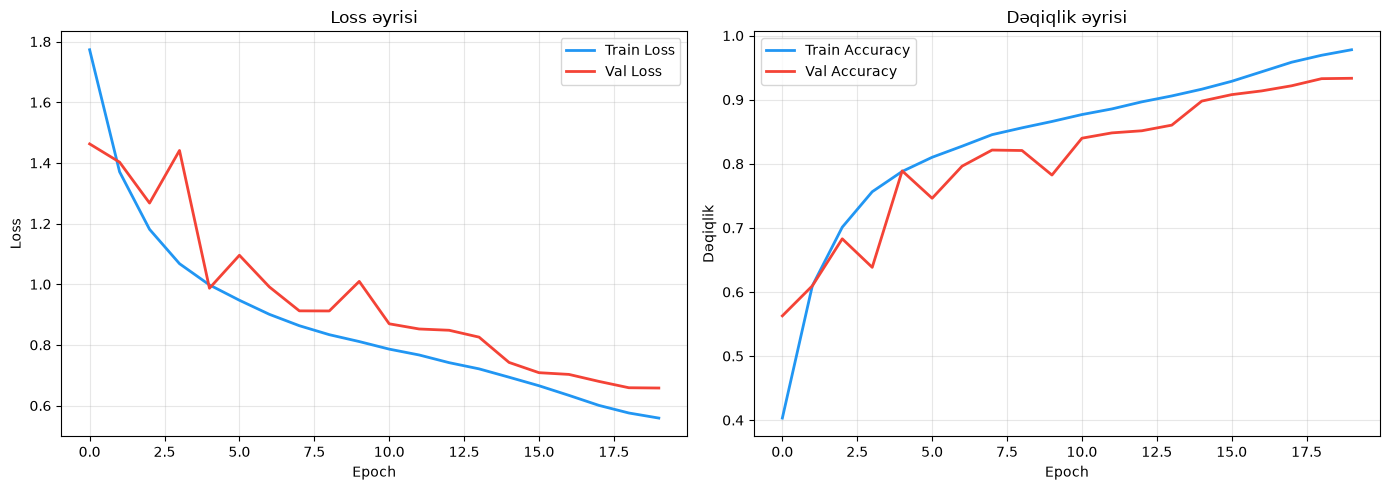

Ən yaxşı val dəqiqliyi: 93.34%


In [23]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sol qrafik — Loss
axes[0].plot(history['train_loss'], label='Train Loss',
             color='#2196F3', linewidth=2)
axes[0].plot(history['val_loss'],   label='Val Loss',
             color='#F44336', linewidth=2)
axes[0].set_title('Loss əyrisi')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Sağ qrafik — Accuracy
axes[1].plot(history['train_acc'], label='Train Accuracy',
             color='#2196F3', linewidth=2)
axes[1].plot(history['val_acc'],   label='Val Accuracy',
             color='#F44336', linewidth=2)
axes[1].set_title('Dəqiqlik əyrisi')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Dəqiqlik')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Ən yaxşı val dəqiqliyi: {best_val_acc:.2%}")

In [24]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# Ən yaxşı modeli yüklə
checkpoint = torch.load('best_model.pth', map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"Yükləndi — Epoch {checkpoint['epoch']}, "
      f"Val Acc: {checkpoint['val_acc']:.2%}")

# Bütün validasiya datasında proqnoz al
_, _, final_preds, final_labels = validate(
    model, val_loader, criterion, device
)

# Sinif adları
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# Classification report
print("\nPer-class nəticələr:")
print(classification_report(
    final_labels,
    final_preds,
    target_names=class_names
))

Yükləndi — Epoch 20, Val Acc: 93.34%

Per-class nəticələr:
              precision    recall  f1-score   support

    airplane       0.93      0.93      0.93      1000
  automobile       0.96      0.97      0.97      1000
        bird       0.92      0.91      0.92      1000
         cat       0.87      0.84      0.85      1000
        deer       0.92      0.95      0.93      1000
         dog       0.89      0.90      0.90      1000
        frog       0.95      0.96      0.95      1000
       horse       0.96      0.95      0.96      1000
        ship       0.96      0.96      0.96      1000
       truck       0.96      0.96      0.96      1000

    accuracy                           0.93     10000
   macro avg       0.93      0.93      0.93     10000
weighted avg       0.93      0.93      0.93     10000



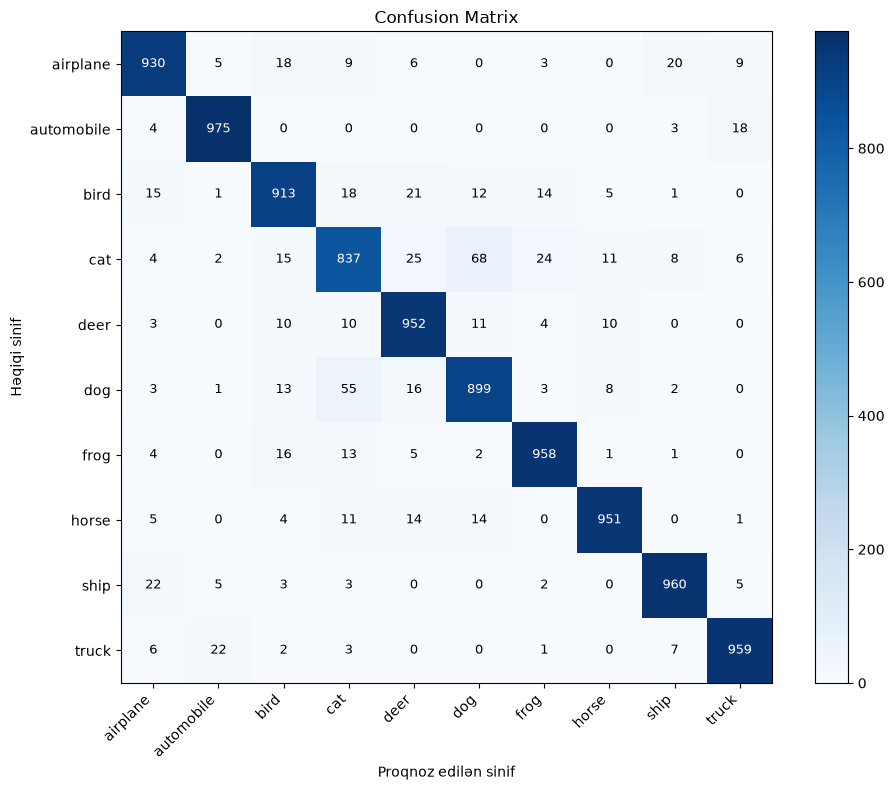

In [25]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(final_labels, final_preds)

fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
plt.colorbar(im)

ax.set_xticks(range(10))
ax.set_yticks(range(10))
ax.set_xticklabels(class_names, rotation=45, ha='right')
ax.set_yticklabels(class_names)

# Hər hücrəyə dəyər yaz
thresh = cm.max() / 2.0
for i in range(10):
    for j in range(10):
        ax.text(j, i, format(cm[i, j], 'd'),
                ha='center', va='center',
                color='white' if cm[i, j] > thresh else 'black',
                fontsize=9)

ax.set_title('Confusion Matrix')
ax.set_ylabel('Həqiqi sinif')
ax.set_xlabel('Proqnoz edilən sinif')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [26]:
from PIL import Image
import torch.nn.functional as F

def predict_single_image(model, image_path, device, class_names):
    """
    Tək şəkil üçün proqnoz funksiyası.
    Hər addım izah olunur.
    """
    model.eval()

    # 1. Şəkli yüklə
    image = Image.open(image_path).convert('RGB')

    # 2. Eyni val transformasiyalarını tətbiq et
    transform = transforms.Compose([
        transforms.Resize((32, 32)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.4914, 0.4822, 0.4465],
            std=[0.2470, 0.2435, 0.2616]
        )
    ])

    # 3. Tensor-a çevir və batch ölçüsü əlavə et
    # Şəkil: (C, H, W) → (1, C, H, W)
    image_tensor = transform(image).unsqueeze(0).to(device)

    # 4. Proqnoz al
    with torch.no_grad():
        logits = model(image_tensor)        # (1, 10)
        probs  = F.softmax(logits, dim=1)   # (1, 10) — cəmi 1.0

        top5_probs, top5_indices = torch.topk(probs, k=5, dim=1)

    # 5. Nəticəni formatla
    print(f"\nProqnoz nəticəsi:")
    print("-" * 35)
    for i in range(5):
        idx  = top5_indices[0][i].item()
        prob = top5_probs[0][i].item()
        marker = " ←" if i == 0 else ""
        print(f"  {class_names[idx]:<12} {prob:>6.2%}{marker}")

    return class_names[top5_indices[0][0].item()], top5_probs[0][0].item()

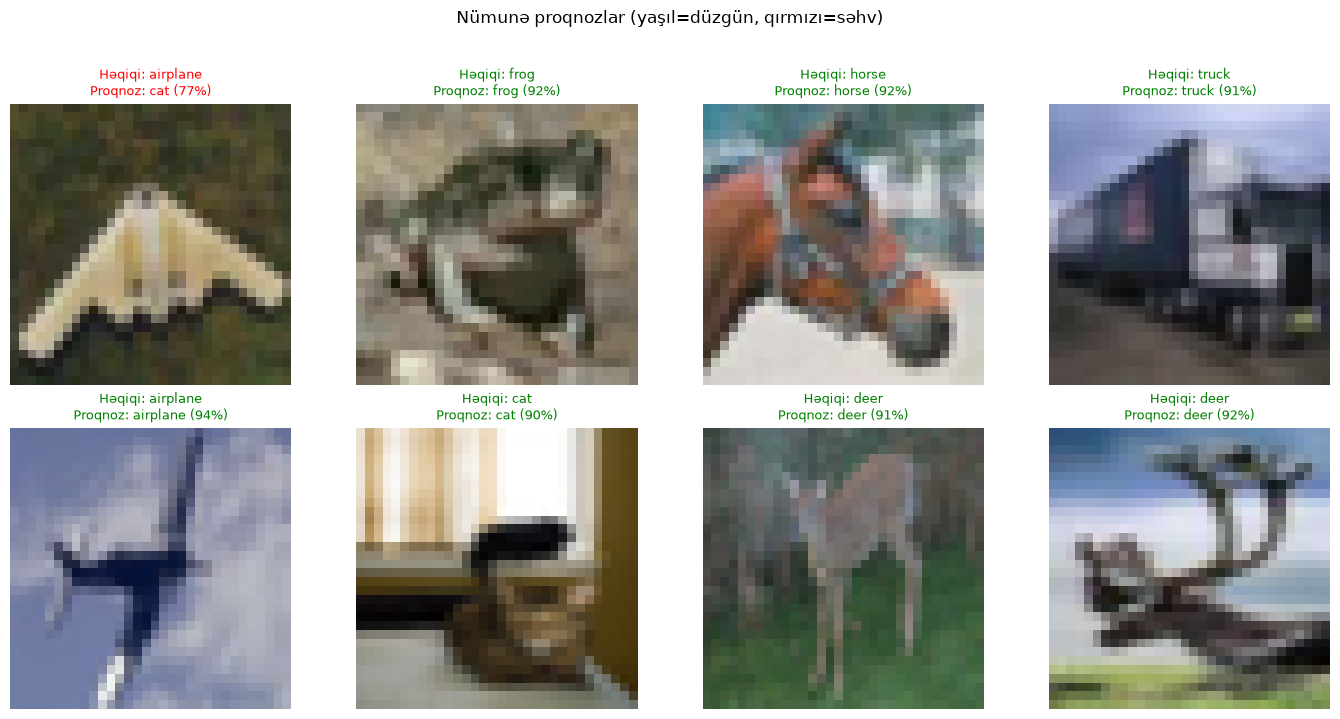

In [28]:
import random
import matplotlib.pyplot as plt

# Validasiya datasından təsadüfi 8 şəkil götür
model.eval()
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.flatten()

# Bir batch götür
sample_images, sample_labels = next(iter(val_loader))
indices = random.sample(range(len(sample_labels)), 8)

with torch.no_grad():
    outputs = model(sample_images.to(device))
    probs   = F.softmax(outputs, dim=1)
    preds   = outputs.argmax(dim=1)

for plot_idx, data_idx in enumerate(indices):
    img   = sample_images[data_idx]
    label = sample_labels[data_idx].item()
    pred  = preds[data_idx].item()
    prob  = probs[data_idx][pred].item()

    # Normallaşdırmanı geri al — göstərmək üçün
    mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3,1,1)
    std  = torch.tensor([0.2470, 0.2435, 0.2616]).view(3,1,1)
    img_show = (img * std + mean).clamp(0, 1)
    img_show = img_show.permute(1, 2, 0).numpy()

    axes[plot_idx].imshow(img_show)
    axes[plot_idx].axis('off')

    correct = (pred == label)
    color   = 'green' if correct else 'red'
    title   = f"Həqiqi: {class_names[label]}\n" \
              f"Proqnoz: {class_names[pred]} ({prob:.0%})"
    axes[plot_idx].set_title(title, color=color, fontsize=9)

plt.suptitle('Nümunə proqnozlar (yaşıl=düzgün, qırmızı=səhv)',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('sample_predictions.png', dpi=150, bbox_inches='tight')
plt.show()